In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix, 
                            accuracy_score, f1_score, precision_score, 
                            recall_score, roc_curve, auc)
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

In [4]:
print("="*70)
print("LOADING MODELS AND DATA")
print("="*70)

test_df = pd.read_csv('C:/Users/Stefan/SBC/Hate_Speech_Recon/Data/Processed/test_processed.csv')
X_test = test_df['tweet_cleaned']
y_test = test_df['class']
tfidf_vectorizer = joblib.load('C:/Users/Stefan/SBC/Hate_Speech_Recon/Models/Saved_models/tfidf_vectorizer.pkl')
X_test_tfidf = tfidf_vectorizer.transform(X_test)

lr_model = joblib.load('C:/Users/Stefan/SBC/Hate_Speech_Recon/Models/Saved_models/logistic_regression.pkl')
svm_model = joblib.load('C:/Users/Stefan/SBC/Hate_Speech_Recon/Models/Saved_models/svm_model.pkl')
nb_model = joblib.load('C:/Users/Stefan/SBC/Hate_Speech_Recon/Models/Saved_models/naive_bayes.pkl')
rf_model = joblib.load('C:/Users/Stefan/SBC/Hate_Speech_Recon/Models/Saved_models/random_forest.pkl')
best_model = joblib.load('C:/Users/Stefan/SBC/Hate_Speech_Recon/Models/Saved_models/best_model.pkl')

with open('C:/Users/Stefan/SBC/Hate_Speech_Recon/Models/Saved_models/model_metadata.json', 'r') as f:
    metadata = json.load(f)
best_model_name = metadata['best_model_name']
print(f"All models and data loaded")
print(f"Test set size: {len(X_test):,}")
print(f"Best model: {best_model_name}")

LOADING MODELS AND DATA
All models and data loaded
Test set size: 4,956
Best model: Linear SVM


In [5]:
models = {
    'Logistic Regression': lr_model,
    'Linear SVM': svm_model,
    'Naive Bayes': nb_model,
    'Random Forest': rf_model
}
predictions = {}
for name, model in models.items():
    predictions[name] = model.predict(X_test_tfidf)
    print(f"Predictions generated for {name}")

Predictions generated for Logistic Regression
Predictions generated for Linear SVM
Predictions generated for Naive Bayes
Predictions generated for Random Forest


In [7]:
print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORTS")
print("="*70)
class_names = ['Hate Speech', 'Offensive Language', 'Neither']

report_text = ""

for name, y_pred in predictions.items():
    print(f"\n{name}:")
    print("-" * 70)
    report = classification_report(y_test, y_pred, target_names=class_names)
    print(report)
    report_text += f"\n{name}:\n{'-'*70}\n{report}\n"

with open('C:/Users/Stefan/SBC/Hate_Speech_Recon/Outputs/Reports/classification_reports.txt', 'w') as f:
    f.write("CLASSIFICATION REPORTS FOR ALL MODELS\n")
    f.write("="*70 + "\n")
    f.write(report_text)

print("\nReports saved to: C:/Users/Stefan/SBC/Hate_Speech_Recon/Outputs/Reports/classification_reports.txt")


DETAILED CLASSIFICATION REPORTS

Logistic Regression:
----------------------------------------------------------------------
                    precision    recall  f1-score   support

       Hate Speech       0.30      0.62      0.41       286
Offensive Language       0.97      0.85      0.91      3838
           Neither       0.78      0.93      0.85       832

          accuracy                           0.85      4956
         macro avg       0.68      0.80      0.72      4956
      weighted avg       0.90      0.85      0.87      4956


Linear SVM:
----------------------------------------------------------------------
                    precision    recall  f1-score   support

       Hate Speech       0.35      0.40      0.37       286
Offensive Language       0.94      0.92      0.93      3838
           Neither       0.82      0.87      0.84       832

          accuracy                           0.88      4956
         macro avg       0.70      0.73      0.72      4956
     


CONFUSION MATRICES


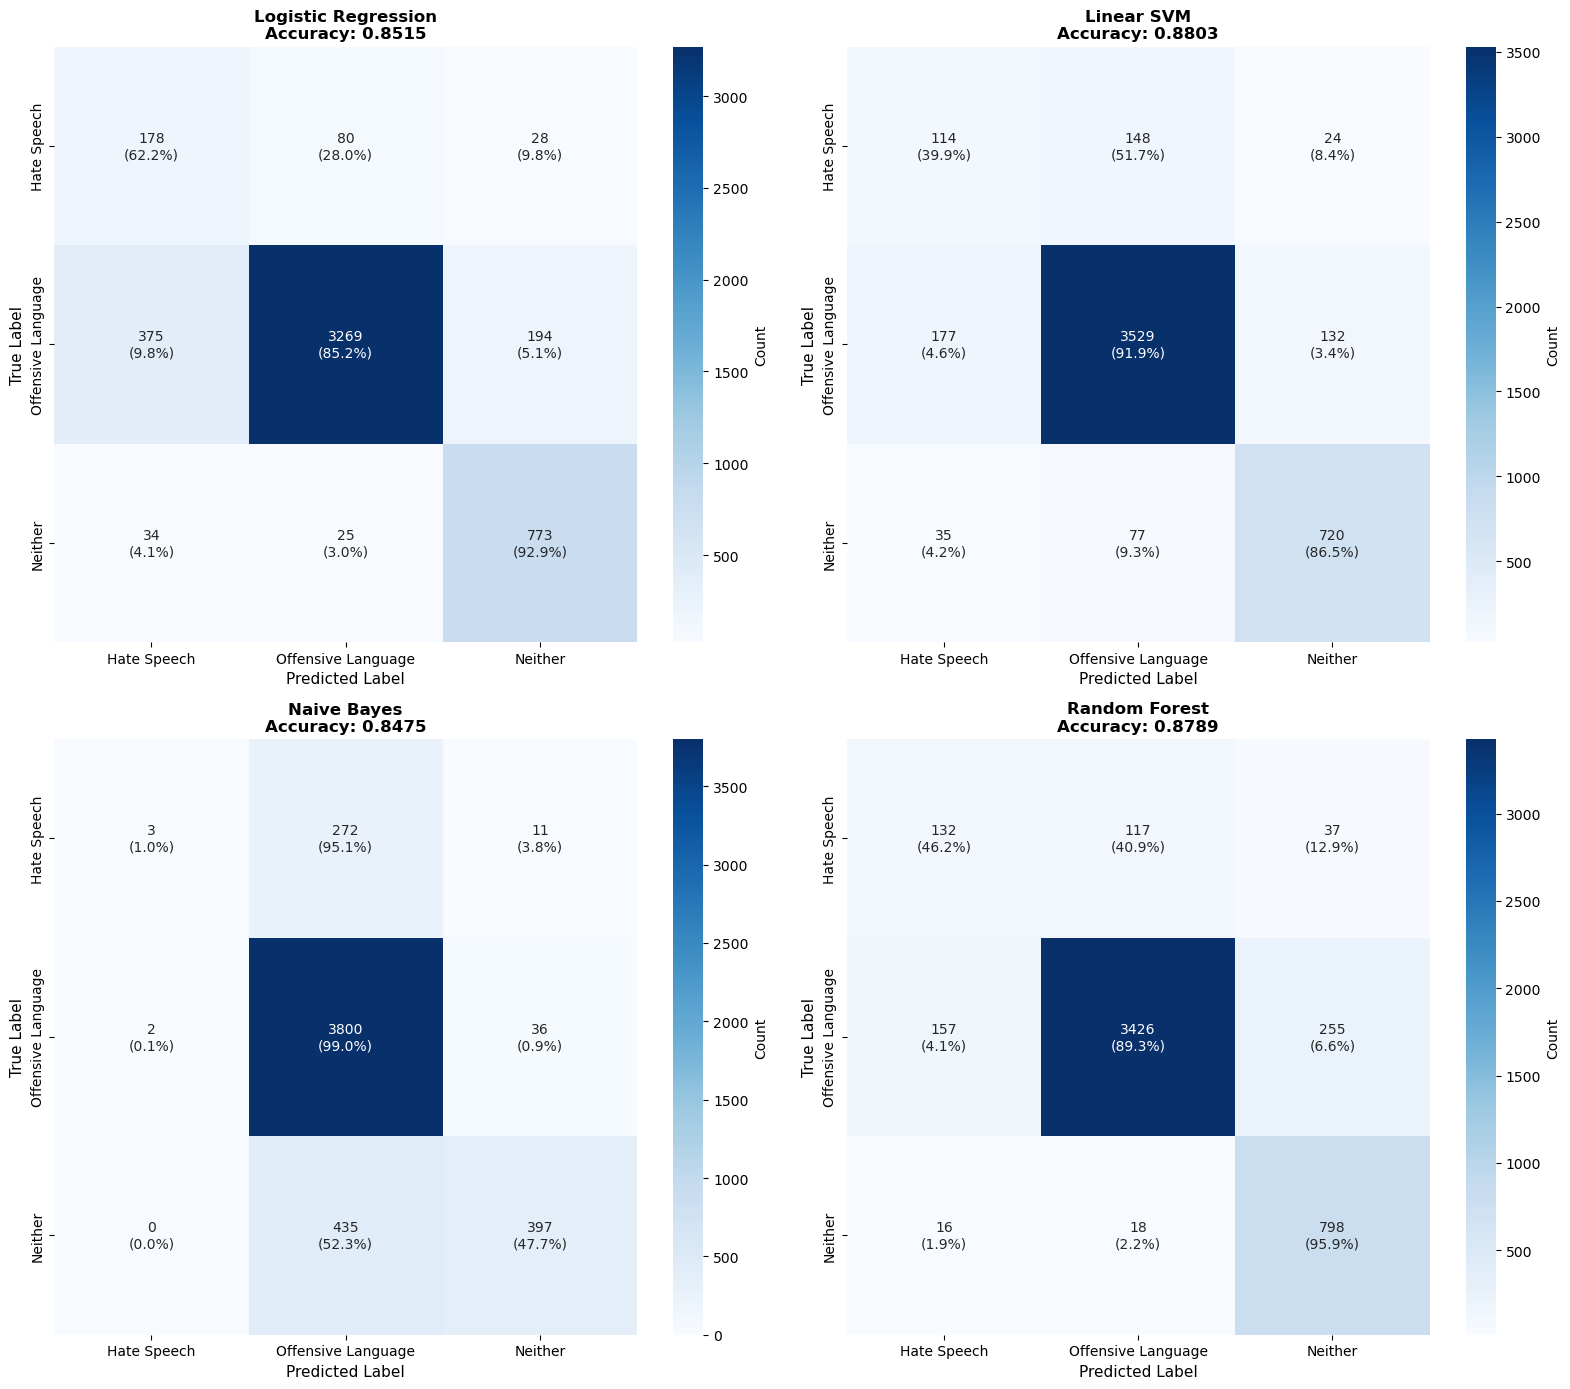

Confusion matrices saved to: C:/Users/Stefan/SBC/Hate_Speech_Recon/Outputs/Figures/confusion_matrices.png


In [8]:
print("\n" + "="*70)
print("CONFUSION MATRICES")
print("="*70)
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.ravel()
for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    annot = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f'{cm[i, j]}\n({cm_percent[i, j]:.1f}%)'

    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=axes[idx],
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    axes[idx].set_title(f'{name}\nAccuracy: {accuracy_score(y_test, y_pred):.4f}', 
                       fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('True Label', fontsize=11)
    axes[idx].set_xlabel('Predicted Label', fontsize=11)
    if name == best_model_name:
        for spine in axes[idx].spines.values():
            spine.set_edgecolor('#FFD700')
            spine.set_linewidth(4)
plt.tight_layout()
plt.savefig('C:/Users/Stefan/SBC/Hate_Speech_Recon/Outputs/Figures/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrices saved to: C:/Users/Stefan/SBC/Hate_Speech_Recon/Outputs/Figures/confusion_matrices.png")


PER-CLASS PERFORMANCE ANALYSIS

Linear SVM - Per-Class Performance:
             Class  Precision   Recall  F1-Score  Support
       Hate Speech   0.349693 0.398601  0.372549      286
Offensive Language   0.940064 0.919489  0.929663     3838
           Neither   0.821918 0.865385  0.843091      832


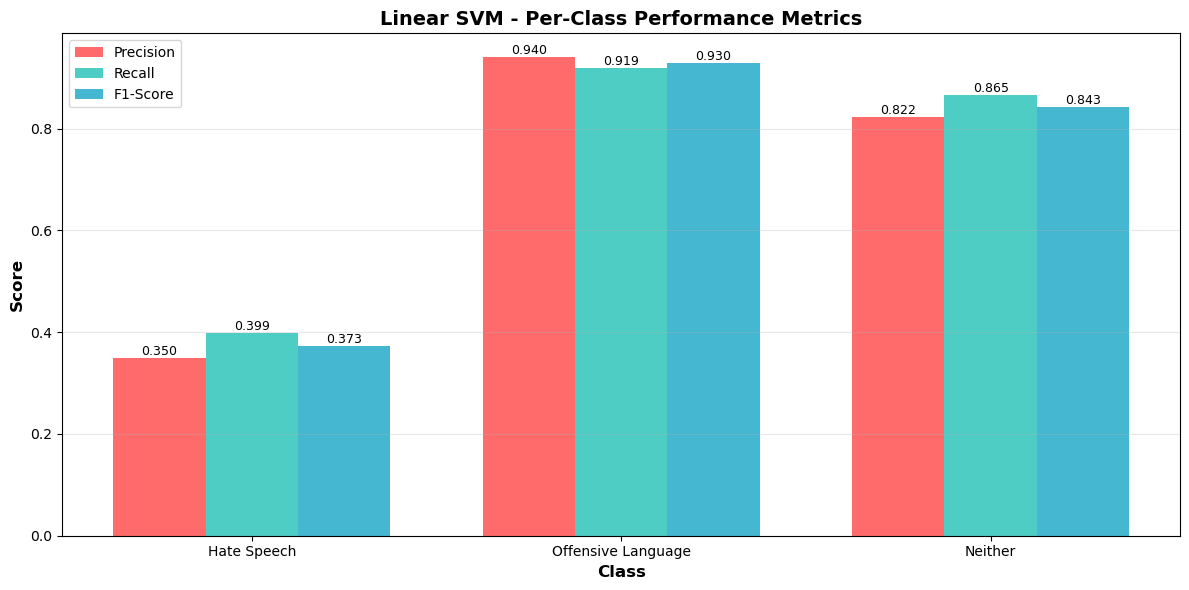


Per-class performance visualization saved


In [9]:
print("\n" + "="*70)
print("PER-CLASS PERFORMANCE ANALYSIS")
print("="*70)
y_pred_best = predictions[best_model_name]

per_class_metrics = []
for class_idx, class_name in enumerate(class_names):
    y_true_binary = (y_test == class_idx).astype(int)
    y_pred_binary = (y_pred_best == class_idx).astype(int)
    
    precision = precision_score(y_true_binary, y_pred_binary, zero_division=0)
    recall = recall_score(y_true_binary, y_pred_binary, zero_division=0)
    f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)
    support = (y_test == class_idx).sum()
    
    per_class_metrics.append({
        'Class': class_name,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Support': support
    })
metrics_df = pd.DataFrame(per_class_metrics)
print(f"\n{best_model_name} - Per-Class Performance:")
print(metrics_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(class_names))
width = 0.25

bars1 = ax.bar(x - width, metrics_df['Precision'], width, label='Precision', color='#FF6B6B')
bars2 = ax.bar(x, metrics_df['Recall'], width, label='Recall', color='#4ECDC4')
bars3 = ax.bar(x + width, metrics_df['F1-Score'], width, label='F1-Score', color='#45B7D1')

ax.set_xlabel('Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title(f'{best_model_name} - Per-Class Performance Metrics', 
            fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('C:/Users/Stefan/SBC/Hate_Speech_Recon/Outputs/Figures/per_class_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPer-class performance visualization saved")

In [10]:
print("\n" + "="*70)
print("ERROR ANALYSIS")
print("="*70)

test_df_copy = test_df.copy()
test_df_copy['predicted'] = y_pred_best
test_df_copy['true_class'] = y_test

misclassified = test_df_copy[test_df_copy['predicted'] != test_df_copy['true_class']]

print(f"\nTotal misclassifications: {len(misclassified):,} / {len(test_df):,}")
print(f"Error rate: {len(misclassified)/len(test_df)*100:.2f}%")

print(f"\nMisclassification patterns:")
misclass_matrix = pd.crosstab(
    misclassified['true_class'].map({0: 'Hate Speech', 1: 'Offensive', 2: 'Neither'}),
    misclassified['predicted'].map({0: 'Hate Speech', 1: 'Offensive', 2: 'Neither'}),
    margins=True
)
print(misclass_matrix)
print(f"\n" + "="*70)
print("SAMPLE MISCLASSIFICATIONS")
print("="*70)

for true_class in [0, 1, 2]:
    print(f"\n{class_names[true_class]} misclassified as:")
    class_errors = misclassified[misclassified['true_class'] == true_class].head(3)
    
    for idx, row in class_errors.iterrows():
        pred_class_name = class_names[row['predicted']]
        print(f"  → Predicted as {pred_class_name}")
        print(f"    Tweet: {row['tweet_cleaned'][:80]}...")
        print()



ERROR ANALYSIS

Total misclassifications: 593 / 4,956
Error rate: 11.97%

Misclassification patterns:
predicted    Hate Speech  Neither  Offensive  All
true_class                                       
Hate Speech            0       24        148  172
Neither               35        0         77  112
Offensive            177      132          0  309
All                  212      156        225  593

SAMPLE MISCLASSIFICATIONS

Hate Speech misclassified as:
  → Predicted as Offensive Language
    Tweet: stfu hoe proud african american proud african american proud white racist...

  → Predicted as Offensive Language
    Tweet: lmao let hoe hoe aint savin nem...

  → Predicted as Offensive Language
    Tweet: man lame niggah find unfollowing as...


Offensive Language misclassified as:
  → Predicted as Neither
    Tweet: dont get spirit bombed lil nigga dragonball trash debate want...

  → Predicted as Neither
    Tweet: microwave work broken ghetto as put hamburger patty toaster warm...
